<a href="https://colab.research.google.com/github/lovnishverma/irisd/blob/main/model-training-notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning



```
!pip install scikit-learn
```



**Scikit-learn** (imported as sklearn in code) is the premier open-source machine learning library for the Python programming language. Built on top of fundamental scientific libraries like NumPy, SciPy, and Matplotlib, it delivers a comprehensive suite of efficient tools for data modeling, predictive analysis, and statistical evaluation.

The package name is formally scikit-learn for installation purposes, whereas **sklearn** is its short-form module handle inside your execution scripts.

https://scikit-learn.org/

**PPT:** https://github.com/lovnishverma/Slidespptspdfs/blob/main/Machine%20Learning/Intro%20to%20Machine%20Learning.pdf

## **Supervised Learning**

## **Classification**

**Hello World Program of ML**

https://en.wikipedia.org/wiki/Iris_flower_data_set

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv")

In [3]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].cov()

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,0.685694,-0.039268,1.273682,0.516904
sepal_width,-0.039268,0.188004,-0.321713,-0.117981
petal_length,1.273682,-0.321713,3.113179,1.296387
petal_width,0.516904,-0.117981,1.296387,0.582414


In [5]:
df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].corr()

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.109369,0.871754,0.817954
sepal_width,-0.109369,1.000000,-0.420516,-0.356544
petal_length,0.871754,-0.420516,1.000000,0.962757
petal_width,0.817954,-0.356544,0.962757,1.000000


In [6]:
df['species'].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


# understanding-and-handling-imbalanced-datasets-in-classification-models

https://blog.devgenius.io/understanding-and-handling-imbalanced-datasets-in-classification-models-bb10ac6fa1a7

In [7]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [8]:
df.isna().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [9]:
df.duplicated().sum()

np.int64(3)

In [10]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')



---



# Step 1

In [11]:
# Load Data

df = pd.read_csv("https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv")

# Step 2

## Separate Features/Target

In [12]:
X = df.drop('species', axis=1)
y = df['species']

**or**

In [13]:
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']] # Features

y = df['species'] # Target

**or**

In [14]:
X = df.iloc[:, :-1] # rows, columns

y = df.iloc[:, -1]

# Step 3

## Train/Test Split is used for Model Evaluation

In [15]:
# train test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4

# Model Training

In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression() # initilize the model

model.fit(X_train, y_train) # Training

LogisticRegression()

# Test on unseen data

In [17]:
pred = model.predict([[6.3,2.8,4.2,1.2]])

print(pred[0])

versicolor


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [18]:
# taking input from user

sepal_length = float(input("Enter sepal_length: "))
sepal_width = float(input("Enter sepal_width: "))
petal_length = float(input("Enter petal_length: "))
petal_width = float(input("Enter petal_width: "))

pred = model.predict([[sepal_length, sepal_width, petal_length, petal_width]])

print(pred[0])

Enter sepal_length: 1
Enter sepal_width: 1
Enter petal_length: 1
Enter petal_width: 1
setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


# Step 5 (Optional)

## Model Evaluation

In [19]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [20]:
# Model accuracy

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")

Accuracy: 1.0


In [21]:
# classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



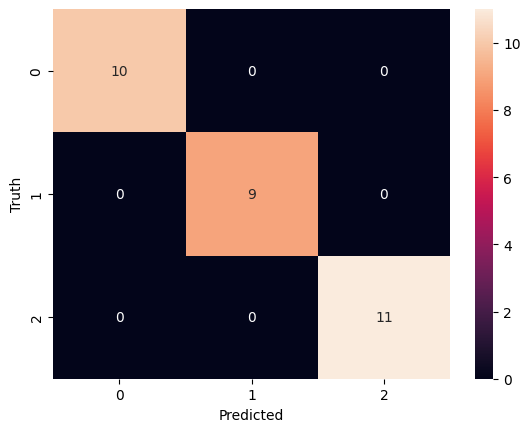

In [22]:
# confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()



---



# Step 6

## Downloading the model for Future Inference



```
!pip install joblib
```



In [23]:
import joblib

# Saving Model

joblib.dump(model, 'model.joblib')

['model.joblib']



---



In [24]:
# Load saved mode

loaded_model = joblib.load('model.joblib')

In [25]:
# pridict from Loaded Model
pred = loaded_model.predict([[6.3,2.8,4.2,1.2]])

print(pred[0])

versicolor


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(




---



Machine learning algorithms are generally divided into **classification** (predicting categories) and **regression** (predicting continuous values). Some algorithms can perform **both**, while others are specialized.

| Algorithm                                | Classification | Regression |
| ---------------------------------------- | :------------: | :--------: |
| Linear Regression                        |        ❌       |      ✅     |
| Logistic Regression                      |        ✅       |      ❌     |
| Decision Tree                            |        ✅       |      ✅     |
| Random Forest                            |        ✅       |      ✅     |
| Extra Trees (Extremely Randomized Trees) |        ✅       |      ✅     |
| K-Nearest Neighbors (KNN)                |        ✅       |      ✅     |
| Support Vector Machine (SVM/SVC)         |        ✅       |      ❌     |
| Support Vector Regression (SVR)          |        ❌       |      ✅     |
| Naive Bayes                              |        ✅       |      ❌     |
| Gaussian Process                         |        ✅       |      ✅     |
| Ridge Regression                         |        ❌       |      ✅     |
| Lasso Regression                         |        ❌       |      ✅     |
| Elastic Net                              |        ❌       |      ✅     |
| SGD (Stochastic Gradient Descent)        |        ✅       |      ✅     |
| AdaBoost                                 |        ✅       |      ✅     |
| Gradient Boosting                        |        ✅       |      ✅     |
| XGBoost                                  |        ✅       |      ✅     |
| LightGBM                                 |        ✅       |      ✅     |
| CatBoost                                 |        ✅       |      ✅     |
| Neural Networks (MLP)                    |        ✅       |      ✅     |

---

## Classification Algorithms

Used when the target variable is **categorical**.

Examples:

* Spam or Not Spam
* Fraud or Legitimate
* Dog, Cat, Horse
* Pass or Fail
* Disease Present or Not

Popular algorithms:

1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier
4. K-Nearest Neighbors (KNN)
5. Support Vector Classifier (SVC)
6. Naive Bayes
7. Gradient Boosting Classifier
8. AdaBoost Classifier
9. XGBoost Classifier
10. LightGBM Classifier
11. CatBoost Classifier
12. Extra Trees Classifier
13. Gaussian Process Classifier
14. MLP Classifier (Neural Network)

---

## Regression Algorithms

Used when the target variable is **continuous**.

Examples:

* House Price
* Salary
* Temperature
* Stock Price
* Sales Prediction

Popular algorithms:

1. Linear Regression
2. Polynomial Regression
3. Ridge Regression
4. Lasso Regression
5. Elastic Net Regression
6. Decision Tree Regressor
7. Random Forest Regressor
8. K-Nearest Neighbors Regressor
9. Support Vector Regression (SVR)
10. Gradient Boosting Regressor
11. AdaBoost Regressor
12. XGBoost Regressor
13. LightGBM Regressor
14. CatBoost Regressor
15. Extra Trees Regressor
16. Gaussian Process Regressor
17. MLP Regressor (Neural Network)

---

## Recommended Learning Order for Beginners

### Classification

1. Logistic Regression
2. KNN Classifier
3. Decision Tree Classifier
4. Random Forest Classifier
5. Naive Bayes
6. SVM (SVC)
7. Gradient Boosting
8. XGBoost
9. LightGBM
10. CatBoost

### Regression

1. Linear Regression
2. Polynomial Regression
3. Ridge Regression
4. Lasso Regression
5. Elastic Net
6. Decision Tree Regressor
7. Random Forest Regressor
8. KNN Regressor
9. SVR
10. Gradient Boosting Regressor
11. XGBoost Regressor
12. LightGBM Regressor
13. CatBoost Regressor

---

## Algorithms Available in scikit-learn

| Classifier                     | Regressor                     |
| ------------------------------ | ----------------------------- |
| LogisticRegression             | LinearRegression              |
| DecisionTreeClassifier         | DecisionTreeRegressor         |
| RandomForestClassifier         | RandomForestRegressor         |
| KNeighborsClassifier           | KNeighborsRegressor           |
| SVC                            | SVR                           |
| GaussianNB                     | —                             |
| SGDClassifier                  | SGDRegressor                  |
| GradientBoostingClassifier     | GradientBoostingRegressor     |
| AdaBoostClassifier             | AdaBoostRegressor             |
| ExtraTreesClassifier           | ExtraTreesRegressor           |
| HistGradientBoostingClassifier | HistGradientBoostingRegressor |
| MLPClassifier                  | MLPRegressor                  |

For a complete beginner in machine learning, a practical sequence is:

* **Regression:** Linear Regression → Polynomial Regression → Decision Tree → Random Forest → Gradient Boosting → XGBoost.
* **Classification:** Logistic Regression → KNN → Decision Tree → Random Forest → Naive Bayes → SVM → XGBoost.

This progression builds intuition with simple models before moving to more powerful ensemble methods commonly used in real-world applications.


# What's Next

If you're learning **regression** in Machine Learning, it's best to start with datasets that gradually increase in complexity.

| Dataset                           |    Rows | Features | Best for                   | Difficulty |
| --------------------------------- | ------: | -------: | -------------------------- | ---------- |
| **Salary Dataset**                |  30–100 |        1 | Simple Linear Regression   | ⭐          |
| **Advertising Dataset**           |     200 |        3 | Multiple Linear Regression | ⭐⭐         |
| **California Housing**            |  20,640 |        8 | Real-world Regression      | ⭐⭐⭐        |
| **House Prices (Ames)**           |   1,460 |       80 | Feature Engineering        | ⭐⭐⭐⭐       |
| **Boston Housing** *(deprecated)* |     506 |       13 | Historical examples only   | ⭐⭐         |
| **Diabetes Dataset**              |     442 |       10 | Healthcare Regression      | ⭐⭐⭐        |
| **Auto MPG**                      |     398 |        8 | Data Cleaning + Regression | ⭐⭐⭐        |
| **Bike Sharing Demand**           | 17,000+ |       12 | Advanced Regression        | ⭐⭐⭐⭐       |

## My recommended learning path

### 1. Salary Dataset (Start Here)

* Goal: Predict salary from years of experience.
* Learn:

  * Scatter plot
  * Linear Regression
  * Train-test split
  * Evaluation metrics

Example:

```
YearsExperience → Salary
```

---

### 2. Advertising Dataset ⭐ (Best for Beginners)

Predict sales based on advertising budget.

Features:

* TV
* Radio
* Newspaper

Target:

* Sales

You'll learn:

* Multiple Linear Regression
* Correlation
* Feature importance
* Residual analysis

Example:

```
TV
Radio
Newspaper
        ↓
      Sales
```

---

### 3. California Housing ⭐⭐⭐ (Highly Recommended)

Available directly in scikit-learn.

Predict:

```
Median House Value
```

Features:

* Median Income
* House Age
* Average Rooms
* Population
* Latitude
* Longitude
* etc.

Perfect for learning:

* Data preprocessing
* Scaling
* Feature engineering
* Random Forest Regression
* Gradient Boosting
* XGBoost (later)

Load it:

```python
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
df = housing.frame
```

---

### 4. House Prices (Ames Housing)

One of the most famous regression datasets.

Target:

```
SalePrice
```

Contains:

* 80+ features
* Missing values
* Categorical variables
* Numerical variables

Excellent for learning:

* Encoding
* Missing value handling
* Pipelines
* Feature engineering

---

### 5. Auto MPG

Predict vehicle fuel efficiency.

Features:

* Cylinders
* Horsepower
* Weight
* Acceleration

Target:

```
MPG
```

You'll practice:

* Cleaning missing values
* Exploratory Data Analysis (EDA)
* Feature scaling
* Regression models

---

## Evaluation Metrics to Learn

For every regression dataset, practice:

* Mean Absolute Error (MAE)
* Mean Squared Error (MSE)
* Root Mean Squared Error (RMSE)
* R² Score
* Adjusted R² (for multiple regression)

---

## Suggested progression of algorithms

1. Simple Linear Regression
2. Multiple Linear Regression
3. Polynomial Regression
4. Decision Tree Regressor
5. Random Forest Regressor
6. Gradient Boosting Regressor
7. XGBoost / LightGBM / CatBoost

---

## Best choice for absolute beginners

1. 🥇 **Advertising Dataset** — Ideal for understanding multiple linear regression with a simple, clean dataset.
2. 🥈 **California Housing** — Best transition to a realistic regression problem using scikit-learn.
3. 🥉 **House Prices (Ames Housing)** — Excellent for end-to-end machine learning projects and feature engineering.

This sequence provides a smooth progression from basic concepts to practical, real-world regression tasks.
